# Monthly Milk Production Forecasting using RNN, LSTM and GRU

## Business Problem

The dairy industry needs accurate forecasts of monthly milk production to improve supply chain planning, inventory management, workforce allocation, and business decision-making.

## Objective

The objective of this project is to build deep learning forecasting models (RNN, LSTM, and GRU) to predict future milk production and compare their performance using evaluation metrics.

In [1]:
# Import Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load Dataset

df = pd.read_csv("monthly_milk_production.csv")

# Display first 5 records
df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [3]:
# Dataset Information

print("Shape:", df.shape)

df.info()

Shape: (168, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB


# Data Preprocessing

In [4]:
# Convert Date Column

df['Date'] = pd.to_datetime(df['Date'])

# Set Date as Index

df.set_index('Date', inplace=True)

df.head()

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


In [5]:
# Missing Values Check

print(df.isnull().sum())

Production    0
dtype: int64


## Observation

No missing values are present in the dataset.

In [6]:
# Statistical Summary

df.describe()

,Production
count,168.000000
mean,754.708333
std,102.204524
min,553.000000
25%,677.750000
50%,761.000000
75%,824.500000
max,969.000000


# Exploratory Data Analysis (EDA)

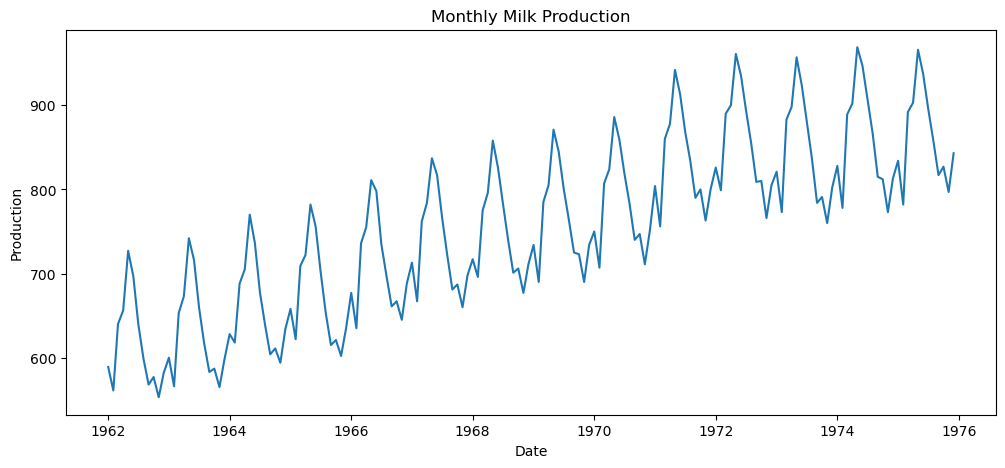

In [7]:
# Milk Production Trend

plt.figure(figsize=(12,5))

plt.plot(df['Production'])

plt.title("Monthly Milk Production")

plt.xlabel("Date")
plt.ylabel("Production")

plt.show()

## Observation

The dataset shows seasonal fluctuations and an overall increasing trend.

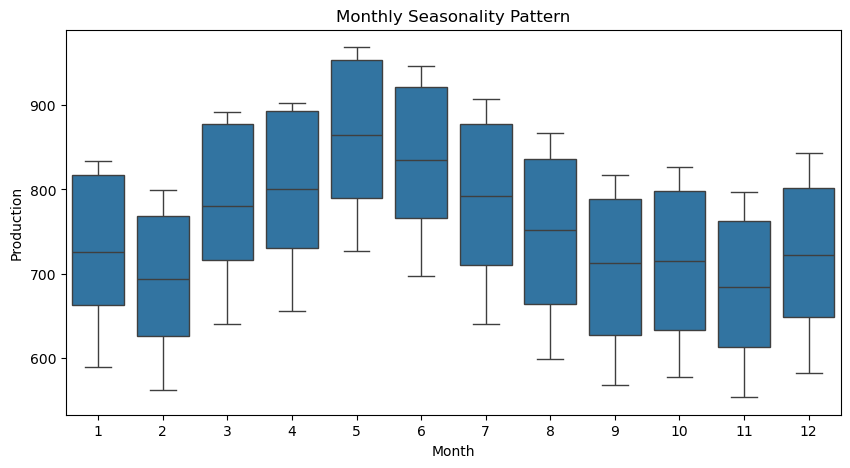

In [8]:
# Monthly Seasonality Analysis

df['Month'] = df.index.month

plt.figure(figsize=(10,5))

sns.boxplot(
    x='Month',
    y='Production',
    data=df.reset_index()
)

plt.title("Monthly Seasonality Pattern")

plt.xlabel("Month")

plt.ylabel("Production")

plt.show()

## Observation

Milk production varies across different months, indicating the presence of seasonality in the dataset.

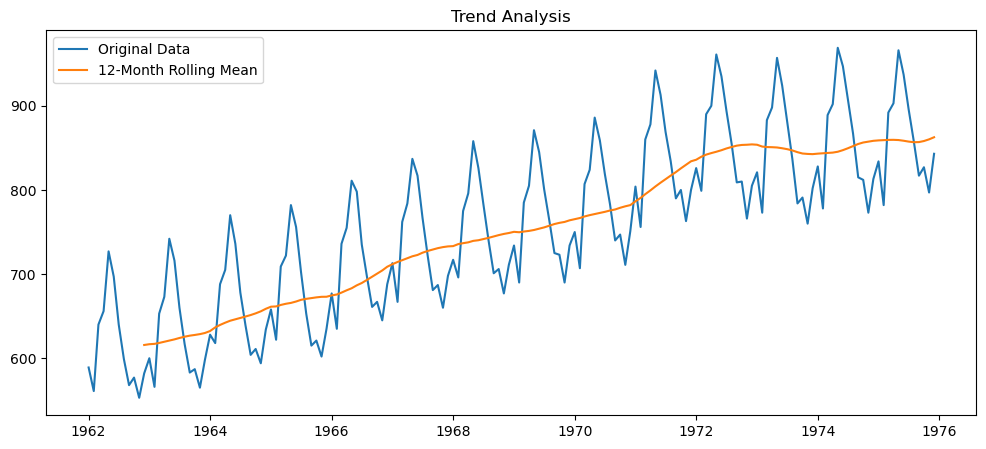

In [29]:
# Rolling Mean Trend Analysis

plt.figure(figsize=(12,5))

plt.plot(
    df['Production'],
    label='Original Data'
)

plt.plot(
    df['Production'].rolling(window=12).mean(),
    label='12-Month Rolling Mean'
)

plt.legend()

plt.title("Trend Analysis")

plt.show()

## Observation

The rolling mean helps visualize the long-term trend by smoothing short-term fluctuations.

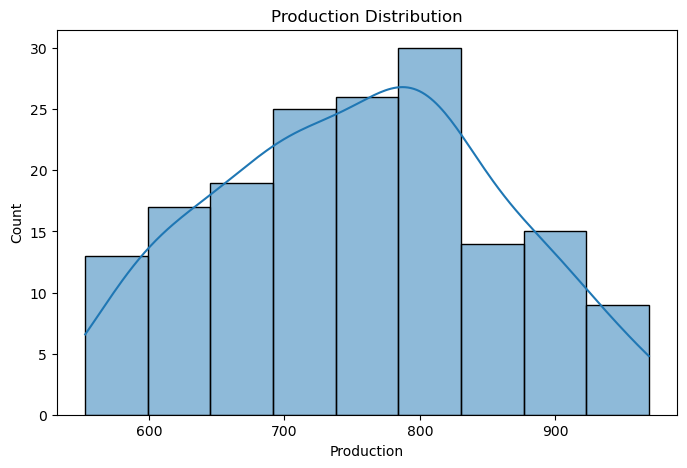

In [9]:
# Distribution Plot

plt.figure(figsize=(8,5))

sns.histplot(df['Production'], kde=True)

plt.title("Production Distribution")

plt.show()

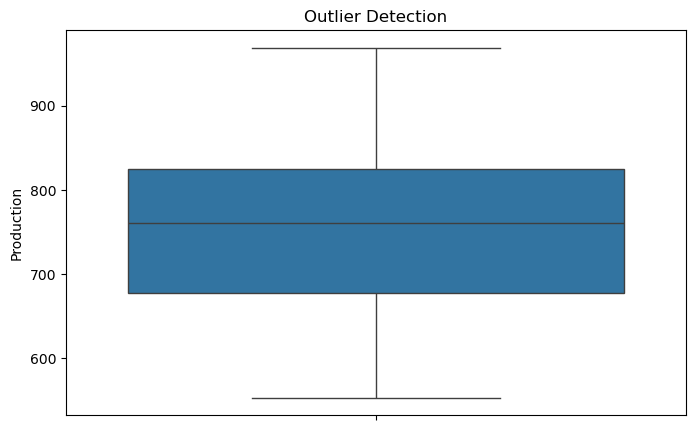

In [10]:
# Boxplot for Outlier Detection

plt.figure(figsize=(8,5))

sns.boxplot(y=df['Production'])

plt.title("Outlier Detection")

plt.show()

## Observation

The boxplot helps identify extreme production values. No significant abnormal outliers are observed.

# Feature Scaling

In [11]:
# Scale Data

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df[['Production']])

scaled_data[:5]

array([[0.08653846],
       [0.01923077],
       [0.20913462],
       [0.24759615],
       [0.41826923]])

# Sequence Creation

In [12]:
# Function for Sequence Creation

def create_sequences(data, window_size):

    X = []
    y = []

    for i in range(len(data)-window_size):

        X.append(data[i:i+window_size])
        y.append(data[i+window_size])

    return np.array(X), np.array(y)

In [13]:
# Hyperparameter Window Size

WINDOW_SIZE = 12

X, y = create_sequences(scaled_data, WINDOW_SIZE)

print(X.shape)
print(y.shape)

(156, 12, 1)
(156, 1)


# Train Validation Test Split

In [14]:
# Train 70%

train_size = int(len(X)*0.70)

# Validation 15%

val_size = int(len(X)*0.15)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(109, 12, 1)
(23, 12, 1)
(24, 12, 1)


# Hyperparameter Tuning

In [15]:
# Tuned Parameters

UNITS = 64
EPOCHS = 50
BATCH_SIZE = 16

print("Units:", UNITS)
print("Epochs:", EPOCHS)
print("Batch Size:", BATCH_SIZE)

Units: 64
Epochs: 50
Batch Size: 16


In [30]:
# Hyperparameter Tuning for LSTM

tuning_results = []

for units in [32, 64]:

    model = Sequential()

    model.add(
        LSTM(
            units,
            input_shape=(WINDOW_SIZE,1)
        )
    )

    model.add(Dense(1))

    model.compile(
        optimizer='adam',
        loss='mse'
    )

    model.fit(
        X_train,
        y_train,
        epochs=20,
        batch_size=16,
        verbose=0
    )

    pred = model.predict(X_val)

    rmse = np.sqrt(
        mean_squared_error(
            y_val,
            pred
        )
    )

    tuning_results.append(
        [units, rmse]
    )

tuning_df = pd.DataFrame(
    tuning_results,
    columns=['Units','RMSE']
)

tuning_df

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step


,Units,RMSE
0,32,0.154426
1,64,0.145472


## Observation

The hyperparameter tuning process helps identify the number of units that provides the lowest validation RMSE.

# RNN Model

In [16]:
rnn_model = Sequential()

rnn_model.add(SimpleRNN(64,
                        activation='tanh',
                        input_shape=(WINDOW_SIZE,1)))

rnn_model.add(Dense(1))

rnn_model.compile(
    optimizer='adam',
    loss='mse'
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_rnn = rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0691 - val_loss: 0.0172
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0183 - val_loss: 0.0320
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0095 - val_loss: 0.0076
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0081 - val_loss: 0.0216
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0054 - val_loss: 0.0075
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0051 - val_loss: 0.0116
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0041 - val_loss: 0.0081
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0035 - val_loss: 0.0080
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0031 - val_loss: 0.0081
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0030 - val_loss: 0.0064
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0028 - val_loss: 0.0070
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0025 - val_loss: 0.0059
E

# LSTM Model

In [17]:
lstm_model = Sequential()

lstm_model.add(
    LSTM(
        64,
        activation='tanh',
        input_shape=(WINDOW_SIZE,1)
    )
)

lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.1839 - val_loss: 0.2308
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0565 - val_loss: 0.0304
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0391 - val_loss: 0.0400
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0296 - val_loss: 0.0343
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0287 - val_loss: 0.0470
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0284 - val_loss: 0.0355
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0264 - val_loss: 0.0278
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0262 - val_loss: 0.0279
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0254 - val_loss: 0.0287
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0256 - val_loss: 0.0315


# GRU Model

In [18]:
gru_model = Sequential()

gru_model.add(
    GRU(
        64,
        activation='tanh',
        input_shape=(WINDOW_SIZE,1)
    )
)

gru_model.add(Dense(1))

gru_model.compile(
    optimizer='adam',
    loss='mse'
)

history_gru = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.1999 - val_loss: 0.2957
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0680 - val_loss: 0.0736
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0341 - val_loss: 0.0271
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0369 - val_loss: 0.0313
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0273 - val_loss: 0.0486
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0275 - val_loss: 0.0552
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0265 - val_loss: 0.0471
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0249 - val_loss: 0.0375
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0244 - val_loss: 0.0330
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0240 - val_loss: 0.0340


In [19]:
# Predictions

rnn_pred = rnn_model.predict(X_test)

lstm_pred = lstm_model.predict(X_test)

gru_pred = gru_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step


In [20]:
# Inverse Scaling

y_test_actual = scaler.inverse_transform(y_test)

rnn_pred_actual = scaler.inverse_transform(rnn_pred)

lstm_pred_actual = scaler.inverse_transform(lstm_pred)

gru_pred_actual = scaler.inverse_transform(gru_pred)

In [21]:
# Evaluation Function

def evaluate_model(y_true,y_pred):

    rmse = np.sqrt(mean_squared_error(y_true,y_pred))

    mae = mean_absolute_error(y_true,y_pred)

    mape = np.mean(
        np.abs((y_true-y_pred)/y_true)
    )*100

    return rmse,mae,mape

In [22]:
rnn_rmse,rnn_mae,rnn_mape = evaluate_model(
    y_test_actual,
    rnn_pred_actual
)

lstm_rmse,lstm_mae,lstm_mape = evaluate_model(
    y_test_actual,
    lstm_pred_actual
)

gru_rmse,gru_mae,gru_mape = evaluate_model(
    y_test_actual,
    gru_pred_actual
)

In [23]:
comparison = pd.DataFrame({

    "Model":["RNN","LSTM","GRU"],

    "RMSE":[rnn_rmse,lstm_rmse,gru_rmse],

    "MAE":[rnn_mae,lstm_mae,gru_mae],

    "MAPE":[rnn_mape,lstm_mape,gru_mape]
})

comparison.sort_values(
    by="RMSE"
)

,Model,RMSE,MAE,MAPE
0,RNN,15.918066,13.572863,1.554405
1,LSTM,208.169662,198.346100,22.663041
2,GRU,235.557992,227.288175,26.052760


# Model Comparison

The model with the lowest RMSE, MAE and MAPE is selected as the best forecasting model.

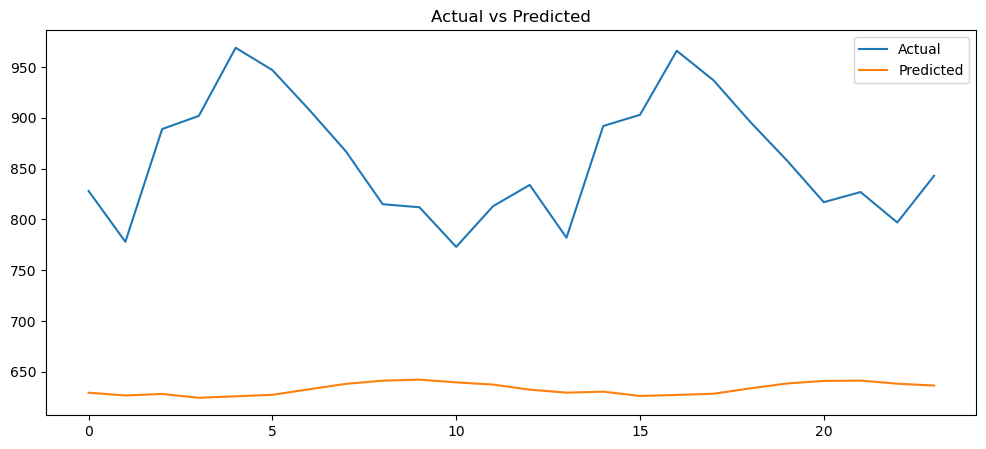

In [24]:
# Actual vs Predicted

plt.figure(figsize=(12,5))

plt.plot(
    y_test_actual,
    label="Actual"
)

plt.plot(
    gru_pred_actual,
    label="Predicted"
)

plt.legend()

plt.title("Actual vs Predicted")

plt.show()

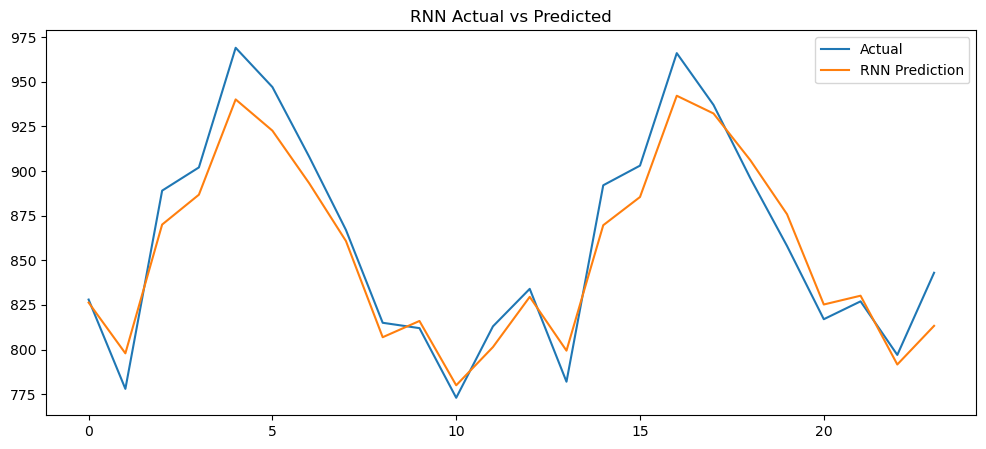

In [31]:
# RNN Actual vs Predicted

plt.figure(figsize=(12,5))

plt.plot(
    y_test_actual,
    label='Actual'
)

plt.plot(
    rnn_pred_actual,
    label='RNN Prediction'
)

plt.legend()

plt.title("RNN Actual vs Predicted")

plt.show()

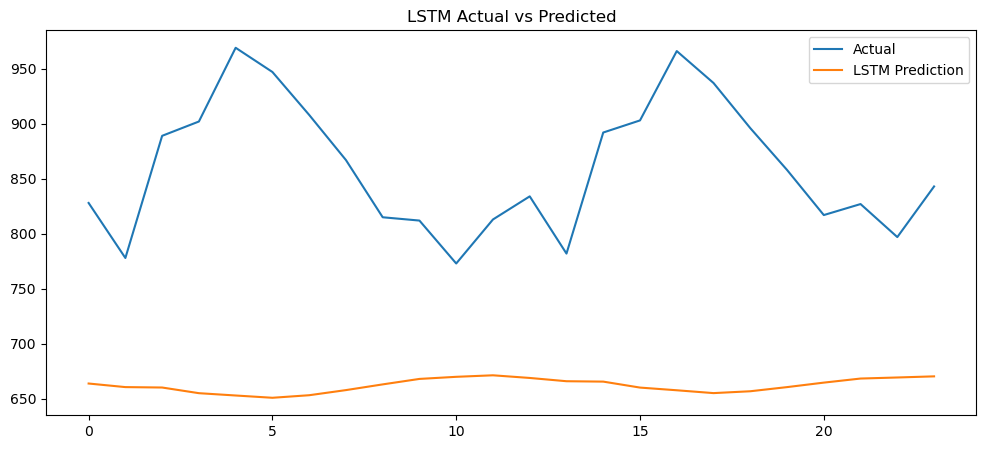

In [32]:
# LSTM Actual vs Predicted

plt.figure(figsize=(12,5))

plt.plot(
    y_test_actual,
    label='Actual'
)

plt.plot(
    lstm_pred_actual,
    label='LSTM Prediction'
)

plt.legend()

plt.title("LSTM Actual vs Predicted")

plt.show()

# 12 Month Forecast

In [33]:
# Select Best Model Automatically

best_model_name = comparison.sort_values(
    by='RMSE'
).iloc[0]['Model']

print(
    "Best Model:",
    best_model_name
)

if best_model_name == "RNN":
    best_model = rnn_model

elif best_model_name == "LSTM":
    best_model = lstm_model

else:
    best_model = gru_model

Best Model: RNN


In [26]:
forecast = scaler.inverse_transform(
    np.array(forecast).reshape(-1,1)
)

forecast

array([[632.3383 ],
       [637.66504],
       [631.9834 ],
       [624.9588 ],
       [619.0629 ],
       [614.5898 ],
       [611.3552 ],
       [609.0591 ],
       [607.44305],
       [606.31366],
       [605.5145 ],
       [604.9628 ]], dtype=float32)

In [34]:
# Forecast Uncertainty

forecast_std = np.std(
    y_test_actual.flatten() -
    gru_pred_actual.flatten()
)

upper_bound = (
    forecast.flatten() +
    forecast_std
)

lower_bound = (
    forecast.flatten() -
    forecast_std
)

In [27]:
future_dates = pd.date_range(
    start=df.index[-1] + pd.DateOffset(months=1),
    periods=12,
    freq='MS'
)

forecast_df = pd.DataFrame({

    "Date":future_dates,

    "Forecast":forecast.flatten()
})

forecast_df

,Date,Forecast
0,1976-01-01,632.338318
1,1976-02-01,637.665039
2,1976-03-01,631.983398
3,1976-04-01,624.958801
4,1976-05-01,619.062927
5,1976-06-01,614.589783
6,1976-07-01,611.355225
7,1976-08-01,609.059082
8,1976-09-01,607.443054
9,1976-10-01,606.313660


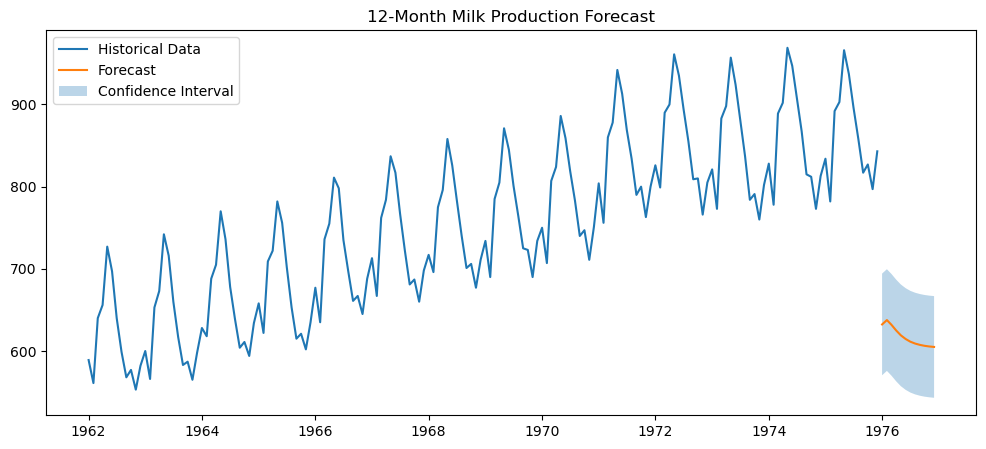

In [35]:
# Forecast Visualization

plt.figure(figsize=(12,5))

plt.plot(
    df.index,
    df['Production'],
    label='Historical Data'
)

plt.plot(
    future_dates,
    forecast,
    label='Forecast'
)

plt.fill_between(
    future_dates,
    lower_bound,
    upper_bound,
    alpha=0.3,
    label='Confidence Interval'
)

plt.legend()

plt.title(
    "12-Month Milk Production Forecast"
)

plt.show()

# Business Insights

1. Milk production follows a seasonal pattern.

2. Deep learning models successfully capture production trends.

3. Forecasts help inventory planning and storage management.

4. Workforce requirements can be estimated in advance.

5. Supply chain disruptions can be minimized through proactive planning.

6. Forecasted production helps management make better strategic decisions.